# Анализ банковских транзакций: кластеризация клиентов

**Автор:** Макаренко Андрей Вячеславович

**Дата:** Март - Апрель 2026

**Цель:** Сегментация клиентов банка для выявления групп риска и разработки потенциальных стратегий удержания

## Содержание
1. Загрузка и предобработка данных
2. Исследовательский анализ данных (EDA)
3. Создание агрегированных признаков
4. Подготовка данных для кластеризации
5. Выбор оптимального числа кластеров
6. Кластеризация
7. Оценка устойчивости кластеров
8. Анализ оттока и стратегии удержания
9. Выводы

---

### 1. Загрузка и предобработка данных

**Исходные данные:**

| Признак | Описание |
|---------|----------|
| `TransactionID` | Уникальный буквенно-цифровой идентификатор транзакции |
| `AccountID` | Уникальный идентификатор счета (несколько транзакций на счет) |
| `TransactionAmount` | Сумма транзакции  |
| `TransactionDate` | Временная метка транзакции (дата и время) |
| `TransactionType` | Тип транзакции: 'Credit' (пополнение) или 'Debit' (списание) |
| `Location` | Географическое местоположение транзакции (город в США) |
| `DeviceID` | Буквенно-цифровой идентификатор устройства, с которого совершена транзакция |
| `IP Address` | IPv4-адрес, связанный с транзакцией (может меняться для некоторых счетов) |
| `MerchantID` | Уникальный идентификатор торговой точки (показывает предпочтения клиента) |
| `AccountBalance` | Баланс счета после транзакции (логически связан с типом и суммой) |
| `PreviousTransactionDate` | Временная метка предыдущей транзакции (для расчета частоты) |
| `Channel` | Канал проведения транзакции (Online, ATM, Branch) |
| `CustomerAge` | Возраст клиента (логически сгруппирован по профессии) |
| `CustomerOccupation` | Профессия клиента (Doctor, Engineer, Student, Retired) |
| `TransactionDuration` | Продолжительность транзакции в секундах  |
| `LoginAttempts` | Количество попыток входа перед транзакцией  |


In [296]:
# импорт нужных библиотек 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering 
from sklearn.model_selection import train_test_split

In [297]:
# загрузка данных
df = pd.read_csv("bank_transactions_data_2.csv") 

In [298]:
# типы данных
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

In [299]:
# проверка пропусков
df.isnull().sum() 

TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64

In [300]:
# преобразуем в нужный тип данных для последующей агрегации
df['TransactionDate'] = pd.to_datetime(df['TransactionDate']) 

---

### 2. Исследовательский анализ данных (EDA)

In [301]:
# определяем временной период исходных данных
print('Дата первой транзакции: ',df['TransactionDate'].min())
print('Дата последней транзакции: ',df['TransactionDate'].max())

date_range = df['TransactionDate'].max() - df['TransactionDate'].min()
print('Длительность периода в днях: ',date_range.days)

Дата первой транзакции:  2023-01-02 16:00:06
Дата последней транзакции:  2024-01-01 18:21:50
Длительность периода в днях:  364


In [302]:
num_clients = df['AccountID'].nunique()
print('Число клиентов: ', num_clients)

Число клиентов:  495


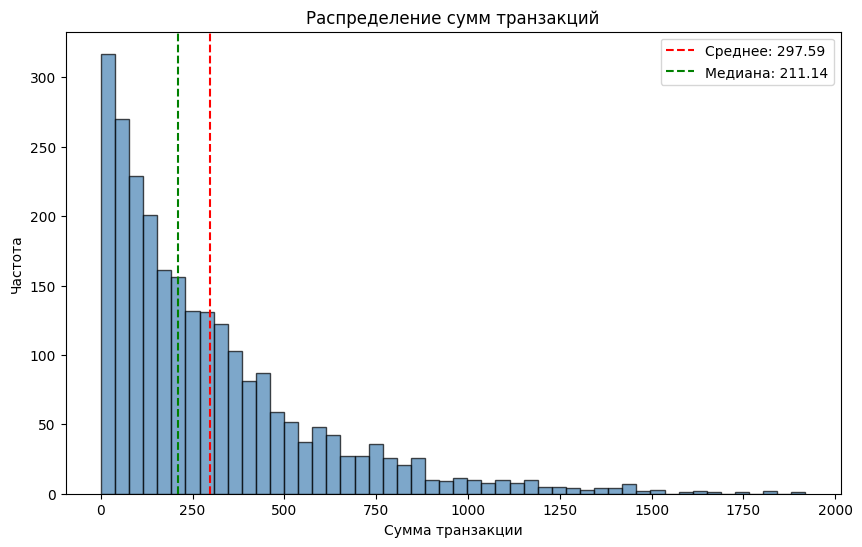

In [303]:
# Распределение сумм транзакций

plt.figure(figsize=(10, 6))
plt.hist(df['TransactionAmount'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Сумма транзакции')
plt.ylabel('Частота')
plt.title('Распределение сумм транзакций')
plt.axvline(df['TransactionAmount'].mean(), color='red', linestyle='--', 
            label=f'Среднее: {df["TransactionAmount"].mean():.2f}')
plt.axvline(df['TransactionAmount'].median(), color='green', linestyle='--', 
            label=f'Медиана: {df["TransactionAmount"].median():.2f}')
plt.legend()
plt.show() 

**Интерпретация:**
- Большинство транзакций имеют небольшую сумму (медиана 211.14)
- Среднее значение (297.59) значительно выше медианы - это указывает на наличие редких крупных транзакций-выбросов
- **Вывод:** при кластеризации необходимо стандартизировать данные, чтобы крупные суммы не доминировали

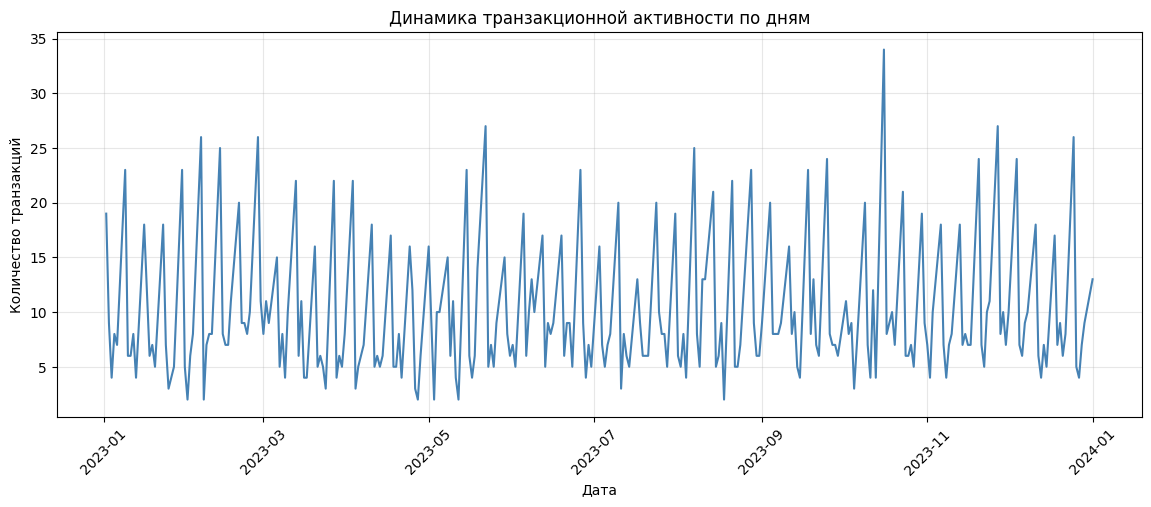

Среднее количество транзакций в день: 9.624521072796934
Максимум транзакций в день: 34 (2023-10-16)
Минимум транзакций в день: 2 (2023-02-01)


In [304]:
# Динамика транзакций по дням
daily_activity = df.groupby(df['TransactionDate'].dt.date).size()

plt.figure(figsize=(14, 5))
daily_activity.plot(color='steelblue', linewidth=1.5)
plt.xlabel('Дата')
plt.ylabel('Количество транзакций')
plt.title('Динамика транзакционной активности по дням')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

print(f"Среднее количество транзакций в день: {daily_activity.mean()}")
print(f"Максимум транзакций в день: {daily_activity.max()} ({daily_activity.idxmax()})")
print(f"Минимум транзакций в день: {daily_activity.min()} ({daily_activity.idxmin()})")

**Интерпретация:**
- Видна сезонность: есть пики активности и периоды спада
- Периоды неактивности могут быть естественными

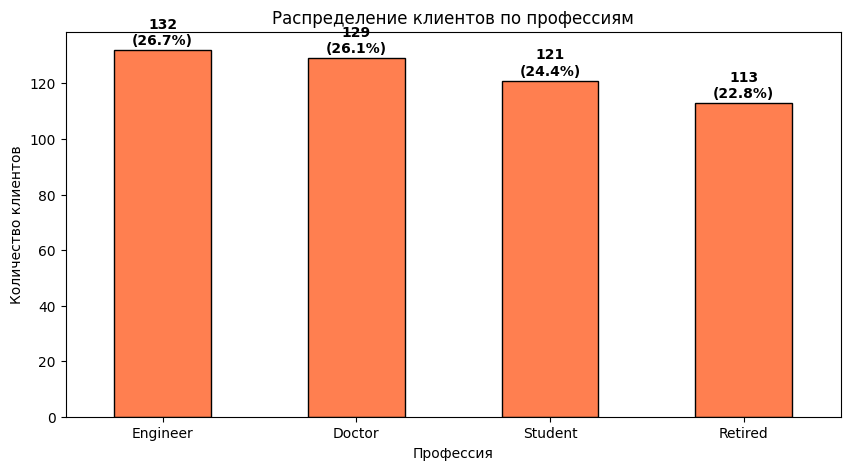

In [305]:
# Распределение по профессиям клиентов
occupation_dist = df.groupby('AccountID')['CustomerOccupation'].first().value_counts()

plt.figure(figsize=(10, 5))
occupation_dist.plot(kind='bar', color='coral', edgecolor='black')
plt.xlabel('Профессия')
plt.ylabel('Количество клиентов')
plt.title('Распределение клиентов по профессиям')
plt.xticks(rotation=0)

for i, (occ, count) in enumerate(occupation_dist.items()):
    plt.text(i, count + 2, f'{count}\n({count/len(df["AccountID"].unique())*100:.1f}%)', 
             ha='center', fontweight='bold')
plt.show()

**Интерпретация:**
- Наиболее многочисленная группа - инжинеры (132 клиента - 26.7%)
- Демографический состав важен для разработки адресных стратегий

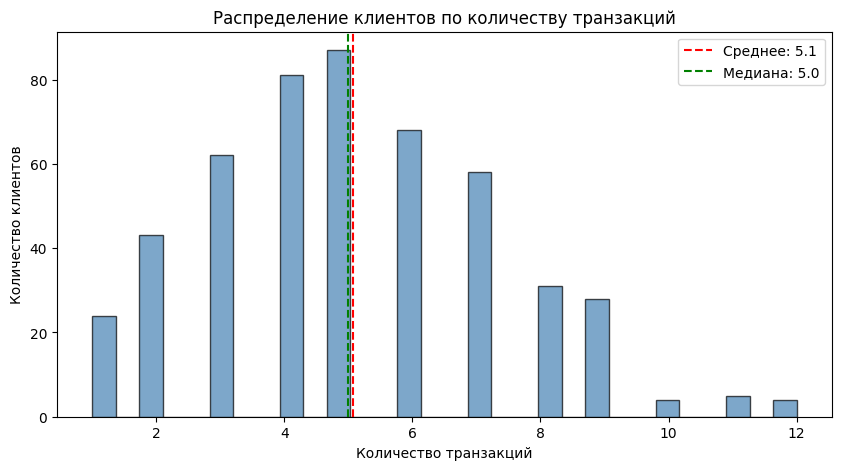

In [306]:
# Распределение по количеству транзакций
transactions_per_customer = df.groupby('AccountID').size()

plt.figure(figsize=(10, 5))
plt.hist(transactions_per_customer, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Количество транзакций')
plt.ylabel('Количество клиентов')
plt.title('Распределение клиентов по количеству транзакций')
plt.axvline(transactions_per_customer.mean(), color='red', linestyle='--', 
            label=f'Среднее: {transactions_per_customer.mean():.1f}')
plt.axvline(transactions_per_customer.median(), color='green', linestyle='--', 
            label=f'Медиана: {transactions_per_customer.median():.1f}')
plt.legend()
plt.show()



**Интерпретация:**
- Большинство клиентов совершают от 3 до 8 транзакций
- Есть небольшое количество очень активных клиентов (>8 транзакций)
- **Вывод:** активность клиентов значительно различается, что делает кластеризацию осмысленной

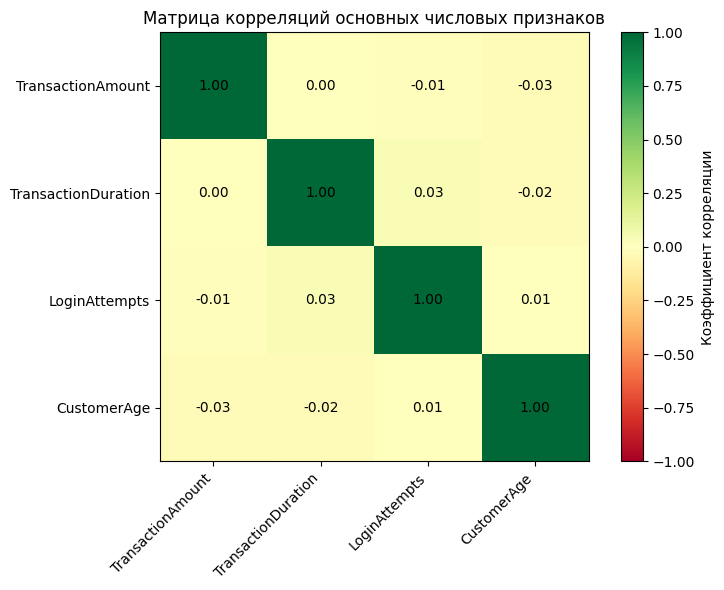

In [307]:
# Матрица корреляций основных числовых признаков
numeric_cols = ['TransactionAmount', 'TransactionDuration', 'LoginAttempts', 'CustomerAge']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(label='Коэффициент корреляции')


plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha='right')
plt.yticks(range(len(numeric_cols)), numeric_cols)

for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        plt.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                 ha="center", va="center", color="black")

plt.title('Матрица корреляций основных числовых признаков')
plt.tight_layout()
plt.show()

**Вывод:**
значимых корреляций между признаками не обнаружено

### Выводы по EDA

**Основные наблюдения:**
1. **Распределения:** суммы транзакций имеют сильную асимметрию, нужна стандартизация
2. **Временные зависимости:** присутсвует сезонность, что может обуславливать естественный спад активности
3. **Демография:** инжинеры — самая многочисленная группа, нужна стандартизация
4. **Корреляции:** значимых корреляций между признаками не обнаружено


---

### 3. Создание агрегированых признаков

In [308]:
# Расчет RFM
# - TransactionDate: вычисляем Recency = разница между текущей датой и датой последней транзакции
# - TransactionID: считаем количество транзакций (Frequency)
# - TransactionAmount: считаем сумму, среднее и стандартное отклонение (Monetary)
now=df['TransactionDate'].max()

rfm = df.groupby('AccountID').agg({
    'TransactionDate': lambda x : (now - x.max()),
    'TransactionID': 'count',
    'TransactionAmount': ['sum', 'mean', 'std'],
})

rfm.columns = ['Recency', 'TransactionCount', 'Sum_Amount', 'Avg_Amount', 'Std_Amount']

rfm


,Recency,TransactionCount,Sum_Amount,Avg_Amount,Std_Amount
AccountID,,,,,
AC00001,48 days 01:25:16,2,260.76,130.380000,116.799898
AC00002,11 days 01:21:00,7,2056.21,293.744286,195.695091
AC00003,90 days 23:24:31,5,1266.34,253.268000,158.484753
AC00004,0 days 02:13:01,9,2180.08,242.231111,231.081586
AC00005,28 days 00:19:57,9,3131.77,347.974444,189.487268
...,...,...,...,...,...
AC00496,250 days 00:26:39,3,595.88,198.626667,141.862904
AC00497,61 days 00:58:04,6,1187.21,197.868333,107.795494
AC00498,0 days 01:47:40,8,3051.02,381.377500,423.171694


In [309]:
# Поведенческие признаки
behavior = df.groupby('AccountID').agg({
    'TransactionDuration': 'mean',
    'LoginAttempts': 'mean',
    'DeviceID': pd.Series.nunique,
    'IP Address': pd.Series.nunique
}) 
behavior

,TransactionDuration,LoginAttempts,DeviceID,IP Address
AccountID,,,,
AC00001,107.500000,1.000000,2,2
AC00002,109.857143,1.142857,7,7
AC00003,49.200000,1.000000,5,5
AC00004,104.333333,1.000000,9,9
AC00005,145.111111,1.000000,9,9
...,...,...,...,...
AC00496,92.666667,1.000000,3,3
AC00497,161.000000,1.000000,6,6
AC00498,131.625000,1.125000,8,8


In [310]:
# демографические признаки
demo = df.groupby('AccountID').agg({
    'CustomerAge': 'mean',
    'CustomerOccupation': 'first'
})

demo


,CustomerAge,CustomerOccupation
AccountID,,
AC00001,42.000000,Student
AC00002,51.857143,Retired
AC00003,56.600000,Doctor
AC00004,53.333333,Retired
AC00005,44.888889,Engineer
...,...,...
AC00496,38.666667,Doctor
AC00497,52.500000,Retired
AC00498,34.375000,Engineer


### Агрегированные признаки 

Для каждого клиента на основе исходных транзакций были рассчитаны следующие агрегированные признаки:

| Признак | Описание |
|---------|----------|
| `Recency` | Количество дней с последней транзакции |
| `TransactionCount` | Общее количество транзакций клиента |
| `Sum_Amount` |  Общая сумма всех транзакций |
| `Avg_Amount` |  Средняя сумма транзакции |
| `Std_Amount` |  Стандартное отклонение суммы (волатильность) |
| `TransactionDuration` |  Средняя продолжительность транзакции |
| `LoginAttempts` | Среднее количество попыток входа |
| `DeviceID` | Количество уникальных устройств |
| `IP Address` | Количество уникальных IP-адресов |
| `CustomerAge` | Средний возраст клиента |
| `CustomerOccupation` | Наиболее часто встречающаяся профессия |

In [311]:
# общая таблица агрегированных признаков
features = pd.concat([rfm, behavior, demo], axis=1)
features

,Recency,TransactionCount,Sum_Amount,Avg_Amount,Std_Amount,TransactionDuration,LoginAttempts,DeviceID,IP Address,CustomerAge,CustomerOccupation
AccountID,,,,,,,,,,,
AC00001,48 days 01:25:16,2,260.76,130.380000,116.799898,107.500000,1.000000,2,2,42.000000,Student
AC00002,11 days 01:21:00,7,2056.21,293.744286,195.695091,109.857143,1.142857,7,7,51.857143,Retired
AC00003,90 days 23:24:31,5,1266.34,253.268000,158.484753,49.200000,1.000000,5,5,56.600000,Doctor
AC00004,0 days 02:13:01,9,2180.08,242.231111,231.081586,104.333333,1.000000,9,9,53.333333,Retired
AC00005,28 days 00:19:57,9,3131.77,347.974444,189.487268,145.111111,1.000000,9,9,44.888889,Engineer
...,...,...,...,...,...,...,...,...,...,...,...
AC00496,250 days 00:26:39,3,595.88,198.626667,141.862904,92.666667,1.000000,3,3,38.666667,Doctor
AC00497,61 days 00:58:04,6,1187.21,197.868333,107.795494,161.000000,1.000000,6,6,52.500000,Retired
AC00498,0 days 01:47:40,8,3051.02,381.377500,423.171694,131.625000,1.125000,8,8,34.375000,Engineer


In [312]:
# преобразуем Recency в тип данных пригодый для машинного обучения
features['Recency'] = features['Recency'].dt.days.astype(float)

**Анализ распределения Recency**

**Примечание:** Recency - производный признак, рассчитываемый после агрегации данных. Его анализ выполняется здесь, после создания всех агрегированных признаков, так как признак формируется на уровне клиента.


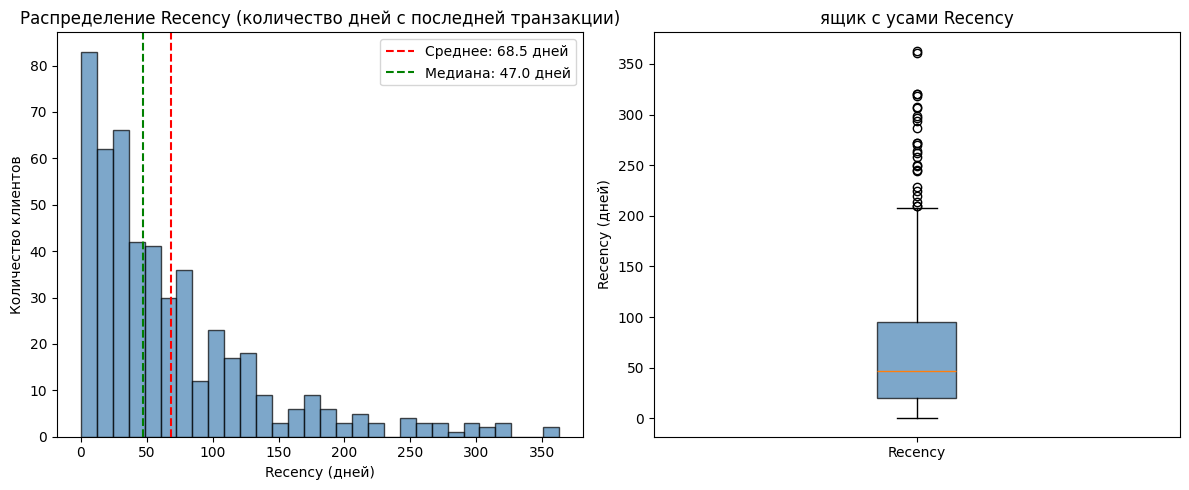

Статистика по recency
Среднее:           68.48 дней
Медиана:           47.00 дней
Минимум:           0.00 дней
Максимум:          363.00 дней
Станд. отклонение: 68.64 дней
Квартиль 25%:      20.00 дней
Квартиль 75%:      95.50 дней


In [313]:
recency_days = features['Recency'].copy()


plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.hist(recency_days, bins=30, edgecolor='black', color='steelblue', alpha=0.7)
plt.axvline(recency_days.mean(), color='red', linestyle='--', label=f'Среднее: {recency_days.mean():.1f} дней')
plt.axvline(recency_days.median(), color='green', linestyle='--', label=f'Медиана: {recency_days.median():.1f} дней')
plt.xlabel('Recency (дней)')
plt.ylabel('Количество клиентов')
plt.title('Распределение Recency (количество дней с последней транзакции)')
plt.legend()


plt.subplot(1, 2, 2)
plt.boxplot(recency_days, vert=True, patch_artist=True, 
            boxprops=dict(facecolor='steelblue', alpha=0.7))
plt.ylabel('Recency (дней)')
plt.title('ящик с усами Recency')
plt.xticks([1], ['Recency'])

plt.tight_layout()
plt.show()

print("Статистика по recency")

print(f"Среднее:           {recency_days.mean():.2f} дней")
print(f"Медиана:           {recency_days.median():.2f} дней")
print(f"Минимум:           {recency_days.min():.2f} дней")
print(f"Максимум:          {recency_days.max():.2f} дней")
print(f"Станд. отклонение: {recency_days.std():.2f} дней")
print(f"Квартиль 25%:      {recency_days.quantile(0.25):.2f} дней")
print(f"Квартиль 75%:      {recency_days.quantile(0.75):.2f} дней")

**Интерпретация:**

| Показатель | Значение |
|------------|----------|
| Среднее | 68.48 дней |
| Медиана | 47.00 дней |
| 25% клиентов | имеют Recency ≤ 20 дней |
| 75% клиентов | имеют Recency ≤ 95.5 дней |


**Наблюдения:**
- Распределение Recency имеет **положительную асимметрию** (среднее > медианы)
- **0–20 дней** → 25% клиентов, очень активные
- **21–47 дней** → 25% клиентов, активные
- **48–95 дней** → 25% клиентов, снижается активность
- **>95 дней** → 25% клиентов, зона риска / потенциальный отток
- Значение около 60 дней можно рассматривать как границу между активными и потенциально неактивными клиентами

**Вывод:** 
- Медиана 47 дней означает, что половина клиентов совершали транзакции в последние 1.5 месяца
- 25% клиентов имеют Recency более 95 дней — это потенциальная зона оттока
- Наличие выбросов (максимум 363 дня) указывает на клиентов, которые давно не активны

---

### 4.Подготовка данных для кластеризации

In [314]:
# кодируем категориальные признаки ohe для обучения модели
features = pd.get_dummies(features, columns=['CustomerOccupation'], drop_first=True)
features.iloc[:, -3:] = features.iloc[:, -3:].astype(int)
features

C:\Users\administrator\AppData\Local\Temp\ipykernel_14364\2852833564.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'AccountID
AC00001    0
AC00002    0
AC00003    0
AC00004    0
AC00005    1
          ..
AC00496    0
AC00497    0
AC00498    1
AC00499    1
AC00500    0
Name: CustomerOccupation_Engineer, Length: 495, dtype: int64' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  features.iloc[:, -3:] = features.iloc[:, -3:].astype(int)
C:\Users\administrator\AppData\Local\Temp\ipykernel_14364\2852833564.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'AccountID
AC00001    0
AC00002    1
AC00003    0
AC00004    1
AC00005    0
          ..
AC00496    0
AC00497    1
AC00498    0
AC00499    0
AC00500    0
Name: CustomerOccupation_Retired, Length: 495, dtype: int64' has dtype incompatible with bool, pleas

,Recency,TransactionCount,Sum_Amount,Avg_Amount,Std_Amount,TransactionDuration,LoginAttempts,DeviceID,IP Address,CustomerAge,CustomerOccupation_Engineer,CustomerOccupation_Retired,CustomerOccupation_Student
AccountID,,,,,,,,,,,,,
AC00001,48.0,2,260.76,130.380000,116.799898,107.500000,1.000000,2,2,42.000000,0,0,1
AC00002,11.0,7,2056.21,293.744286,195.695091,109.857143,1.142857,7,7,51.857143,0,1,0
AC00003,90.0,5,1266.34,253.268000,158.484753,49.200000,1.000000,5,5,56.600000,0,0,0
AC00004,0.0,9,2180.08,242.231111,231.081586,104.333333,1.000000,9,9,53.333333,0,1,0
AC00005,28.0,9,3131.77,347.974444,189.487268,145.111111,1.000000,9,9,44.888889,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
AC00496,250.0,3,595.88,198.626667,141.862904,92.666667,1.000000,3,3,38.666667,0,0,0
AC00497,61.0,6,1187.21,197.868333,107.795494,161.000000,1.000000,6,6,52.500000,0,1,0
AC00498,0.0,8,3051.02,381.377500,423.171694,131.625000,1.125000,8,8,34.375000,1,0,0


Я использовал параметр `drop_first=True` в `pd.get_dummies()` для:

1. **Избежания мультиколлинеарности**
2. **Упрощения модели**
   - Достаточно 3 признаков, чтобы закодировать 4 категории
   - Если все 3 признака = 0, значит клиент — Doctor
   
Так что пока у нас не будет столбца Doctor (при необходимсоти его будет легко вычислить)

In [315]:
# проверка пропусков
features.isna().sum()

Recency                         0
TransactionCount                0
Sum_Amount                      0
Avg_Amount                      0
Std_Amount                     24
TransactionDuration             0
LoginAttempts                   0
DeviceID                        0
IP Address                      0
CustomerAge                     0
CustomerOccupation_Engineer     0
CustomerOccupation_Retired      0
CustomerOccupation_Student      0
dtype: int64

Вероятно при наличии только 1 транзакции стандартное отклонение заполняется некорректно

In [316]:
# смотрим на кол-во транзакций и Std
users_with_nan_std = features[features['Std_Amount'].isna()]


users_with_nan_std['TransactionCount'].value_counts()

TransactionCount
1    24
Name: count, dtype: int64

In [317]:
# заполняем пропуски 0 т.к. если транзакция только одна значит отклонения нет
features['Std_Amount'] = features['Std_Amount'].fillna(0)


In [318]:
# стандартизация данных
scaler = StandardScaler()
f_scaled = scaler.fit_transform(features) 

In [319]:
f_scaled

array([[-0.29864352, -1.34154674, -1.31860273, ..., -0.60302269,
        -0.54388557,  1.75809815],
       [-0.83821696,  0.84000923,  0.57621424, ..., -0.60302269,
         1.83862203, -0.56879646],
       [ 0.31384526, -0.03261316, -0.25737014, ..., -0.60302269,
        -0.54388557, -0.56879646],
       ...,
       [-0.99863069,  1.27632042,  1.62608078, ...,  1.6583124 ,
        -0.54388557, -0.56879646],
       [-0.48822337,  0.84000923,  0.85596477, ...,  1.6583124 ,
        -0.54388557, -0.56879646],
       [ 0.22634686, -0.46892435, -0.91102896, ..., -0.60302269,
        -0.54388557,  1.75809815]], shape=(495, 13))

---

### 5.Выбор оптимального числа кластеров

**Метод локтя**

Для выбора оптимального числа кластеров используем метод локтя - анализ суммы квадратов расстояний (inertia) при разном количестве кластеров. Для начала я решил сделать это на НЕ стандартизированных данных

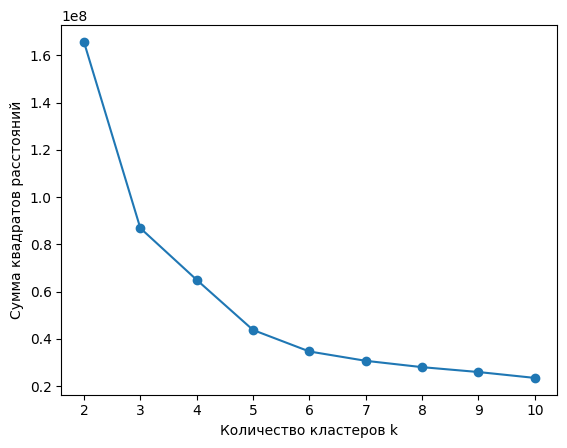

In [320]:
inertia = []
K_range = range(2, 11)  

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(features)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel('Количество кластеров k')
plt.ylabel('Сумма квадратов расстояний')
plt.show()

**Интерпретация (нестандартизированные данные):**

На графике виден **перегиб (локоть) при k ~ (4-5)**. После, снижение инерции резко замедляется.

- Признаки имеют **разный масштаб**
- KMeans минимизирует евклидово расстояние, где **крупные признаки доминируют**
- Фактически кластеризация определяется в основном суммой транзакций (Sum_Amount)
- Это дает **несколько искаженную** картину

**Вывод:** график показывает 4 кластера, но результаты искажены из-за разного масштаба признаков.

Теперь применим метод к стандартизованым данным

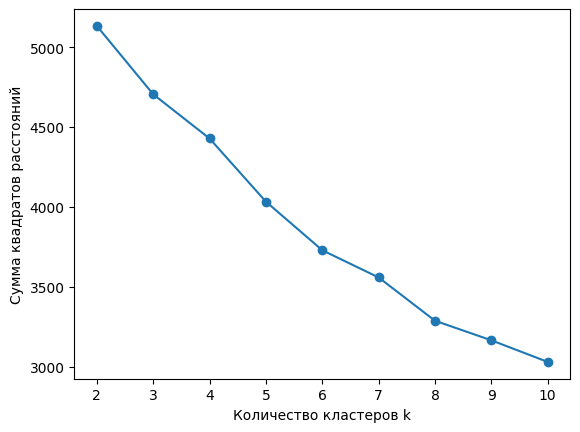

In [321]:
inertia = []
K_range = range(2, 11)  

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(f_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel('Количество кластеров k')
plt.ylabel('Сумма квадратов расстояний')
plt.show()

**Интерпретация (стандартизированные данные):**

На стандартизированных данных график инерции **не имеет ярко выраженного локтя**. Кривая снижается плавно, без резкого перегиба.

- После стандартизации все признаки приведены к **единому масштабу** (среднее = 0, стандартное отклонение = 1)
- Каждый признак вносит **равный вклад** в расстояние между точками
- Данные становятся более "сбалансированными", и естественные кластеры могут перекрываться

**Вывод:** метод локтя не дает однозначного ответа, указывая лишь примерный диапазон.

Так как метод локтя не дал однозначного результата построим дендрограмму иерархической кластеризации. Для данных на 495 клиентов полная дендрограмма нечитаема, поэтому визуализируем только последние 7 этапов объединения кластеров(p=7).

C:\Users\administrator\AppData\Local\Temp\ipykernel_14364\1621335168.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


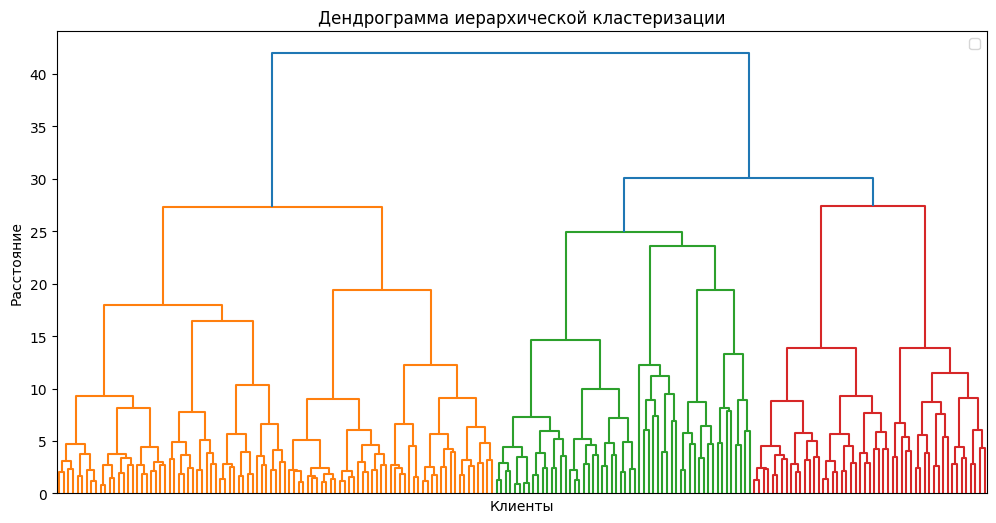

In [322]:
# Дендрограмма для выбора числа кластеров

lin = linkage(f_scaled, method='ward')
plt.figure(figsize=(12, 6))
dendrogram(lin, truncate_mode='level', p=7, no_labels=True)

plt.xlabel('Клиенты')
plt.ylabel('Расстояние')
plt.title('Дендрограмма иерархической кластеризации')
plt.legend()
plt.show()

**Интерпретация дендрограммы:**

-На дендрограмме наблюдается значительный скачок расстояния при объединении кластеров выше уровня ~25, что указывает на наличие 3–4 устойчивых сегментов.

-При более высоком уровне остаётся 3 кластера, однако в этом случае происходит объединение уже достаточно разных групп, и сегментация становится слишком грубой.

-При более низком уровне получается 5–6 кластеров, но такие кластеры уже слабо отличаются друг от друга и избыточны с точки зрения интерпретации.

Таким образом, диапазон разумного числа кластеров находится между 3 и 5, а выбор 4 кластеров является компромиссом между детализацией и интерпретируемостью.

**ВЫВОД:** дендрограмма подтверждает выбор **k=4**.

---

### 6. Кластеризация 

Разбивать на кластеры буду с помощью алгортима k-means из sklearn

In [323]:
# создаем модель и обучаем
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(f_scaled)

features['Cluster'] = clusters


In [324]:
# вычислаем средние значения всех признаков для каждого кластера(профили кластеров)
product_features = features.groupby('Cluster').mean()
product_features

,Recency,TransactionCount,Sum_Amount,Avg_Amount,Std_Amount,TransactionDuration,LoginAttempts,DeviceID,IP Address,CustomerAge,CustomerOccupation_Engineer,CustomerOccupation_Retired,CustomerOccupation_Student
Cluster,,,,,,,,,,,,,
0,67.871795,4.641026,1234.628205,268.092293,236.181228,128.236447,1.884921,4.641026,4.641026,43.239621,0.333333,0.179487,0.153846
1,39.617486,7.387978,2366.151694,327.530068,297.257782,122.107791,1.100821,7.338798,7.338798,43.927403,0.289617,0.191257,0.289617
2,135.040000,2.900000,561.962300,196.683445,116.013652,133.335833,1.018833,2.900000,2.900000,40.492833,0.220000,0.060000,0.490000
3,60.670520,3.982659,1215.046705,320.125991,269.360634,108.034008,1.021869,3.965318,3.959538,47.992004,0.254335,0.375723,0.075145


---

### 7.Оценка устойчивости кластеров

Устойчивость кластеров показывает, насколько надежны результаты кластеризации. Если кластеры устойчивы, они не зависят от случайной инициализации и сохраняются на разных выборках данных.

**Проверка устойчивости на разных выборках (train/test split)**

**Логика проверки:**

Устойчивость кластеров проверяется на разделенных данных:

1. Все клиенты (495 человек) случайным образом делятся на две выборки:
   - **Обучающая выборка (train)** — 70% клиентов (~346 человек)
   - **Тестовая выборка (test)** — 30% клиентов (~149 человек)

2. Модель KMeans обучается **только на обучающей выборке** - она ищет оптимальную структуру среди 346 клиентов.

3. Обученная модель применяется к тестовой выборке - для "невидимых" ранее 149 клиентов определяются номера кластеров.

4. Сравнивается распределение клиентов по кластерам на обеих выборках.

**Критерий устойчивости:**  
Если пропорции кластеров на обучающей и тестовой выборках близки, кластерная структура считается устойчивой. Это означает, что результаты кластеризации не случайны и могут использоваться для дальнейшего анализа.

In [325]:
# Проверка на разных выборках
X_train, X_test = train_test_split(f_scaled, test_size=0.3, random_state=42)

kmeans_train = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters_train = kmeans_train.fit_predict(X_train)
clusters_test = kmeans_train.predict(X_test)

sravnenie = pd.DataFrame({
    'Кластер': range(4),
    'Train (абс)': pd.Series(clusters_train).value_counts().sort_index().values,
    'Train (%)': (pd.Series(clusters_train).value_counts().sort_index().values / len(clusters_train) * 100).round(1),
    'Test (абс)': pd.Series(clusters_test).value_counts().sort_index().values,
    'Test (%)': (pd.Series(clusters_test).value_counts().sort_index().values / len(clusters_test) * 100).round(1)
})
sravnenie['Отклонение (%)'] = (sravnenie['Train (%)'] - sravnenie['Test (%)']).round(1).abs()

sravnenie

,Кластер,Train (абс),Train (%),Test (абс),Test (%),Отклонение (%)
0,0,127,36.7,60,40.3,3.6
1,1,111,32.1,52,34.9,2.8
2,2,58,16.8,19,12.8,4.0
3,3,50,14.5,18,12.1,2.4


Отклонения по выборкам для каждого кластера НЕ превышают 4%.

**Вывод:** кластерная структура устойчива, результаты не зависят от случайного разбиения данных. Модель корректно выделяет кластеры, которые сохраняются на новых данных.

### 8.Анализ оттока и стратегии удержания


**Определение оттока:**  
Клиент считается ушедшим (churn), если с его последней транзакции прошло **более 60 дней**.  
Порог выбран на основе распределения Recency: медиана 47 дней, Q3 = 95.5 дней.

| Метрика | Формула | Описание |
|---------|---------|----------|
| `churn_rate` | `(cluster_data['Recency'] > 60).mean()` | Доля клиентов, не совершавших транзакций более 60 дней |
| `retention_rate` | `(cluster_data['Recency'] <= 60).mean()` | Доля активных клиентов (транзакция была в последние 60 дней) |

In [326]:
# расчет метрик по кластерам
results = []

for cluster_id in features['Cluster'].unique():
    cluster_data = features[features['Cluster'] == cluster_id]
    
    churn_rate = (cluster_data['Recency'] > 60).mean()
    retention_rate = (cluster_data['Recency'] <= 60).mean()
    
 
    results.append({
        'Cluster': cluster_id,
        'churn_rate': churn_rate,
        'retention_rate': retention_rate
    })


churn_retention_df = pd.DataFrame(results)
churn_retention_df = churn_retention_df.sort_values(by='Cluster')
churn_retention_df.reset_index(drop=True)

,Cluster,churn_rate,retention_rate
0,0,0.589744,0.410256
1,1,0.191257,0.808743
2,2,0.730000,0.270000
3,3,0.404624,0.595376


In [327]:
# Размеры кластеров
clusters_size=features.groupby('Cluster').size().reset_index(name='count')

In [328]:
# Объединение данных: размеры, метрики оттока, профили
product = clusters_size.merge(churn_retention_df, on='Cluster')

# Добавляем столбец с долей докторов(так как мы убирали его на этапе подготовки к кластеризации)
product_features['CustomerOccupation_Doctor'] = 1 - (product_features['CustomerOccupation_Engineer'] + 
                                   product_features['CustomerOccupation_Retired'] + 
                                   product_features['CustomerOccupation_Student'])

product= product.merge(product_features, on='Cluster')
print(product)

   Cluster  count  churn_rate  retention_rate     Recency  TransactionCount  \
0        0     39    0.589744        0.410256   67.871795          4.641026   
1        1    183    0.191257        0.808743   39.617486          7.387978   
2        2    100    0.730000        0.270000  135.040000          2.900000   
3        3    173    0.404624        0.595376   60.670520          3.982659   

    Sum_Amount  Avg_Amount  Std_Amount  TransactionDuration  LoginAttempts  \
0  1234.628205  268.092293  236.181228           128.236447       1.884921   
1  2366.151694  327.530068  297.257782           122.107791       1.100821   
2   561.962300  196.683445  116.013652           133.335833       1.018833   
3  1215.046705  320.125991  269.360634           108.034008       1.021869   

   DeviceID  IP Address  CustomerAge  CustomerOccupation_Engineer  \
0  4.641026    4.641026    43.239621                     0.333333   
1  7.338798    7.338798    43.927403                     0.289617   
2  2.9

### Итоговый профиль кластеров:

| Кластер | Размер | Отток | Удержание | Recency | Кол-во транз. | Средний чек | Возраст | Доктора | Инженеры | Пенсионеры | Студенты |
|---------|--------|-------|-----------|---------|---------------|-------------|---------|---------|----------|------------|----------|
| **0** | 39 | 59.0% | 41.0% | 67.9 | 4.6 | 268.1 | 43.2 | 33.3% | 33.3% | 17.9% | 15.4% |
| **1** | 183 | 19.1% | 80.9% | 39.6 | 7.4 | 327.5 | 43.9 | 23.0% | 29.0% | 19.1% | 29.0% |
| **2** | 100 | 73.0% | 27.0% | 135.0 | 2.9 | 196.7 | 40.5 | 23.0% | 22.0% | 6.0% | 49.0% |
| **3** | 173 | 40.5% | 59.5% | 60.7 | 4.0 | 320.1 | 48.0 | 29.5% | 25.4% | 37.6% | 7.5% |

### Интерпретация кластеров

**Примечание:**  
Предложенные ниже стратегии разработаны на основе поведенческих и демографических профилей кластеров. Поскольку исходные данные содержат только транзакционную активность и профессии клиентов (без дополнительной информации, истории коммуникаций и фактических результатах A/B-тестов), рекомендации носят **гипотетический характер** и отражают логику, которую можно было бы применить при наличии соответствующих данных и возможностей для их реализации.

#### Кластер 1 — Лояльные клиенты (183 клиента, 80.9% удержания)

**Характеристики:**
- **Высокая активность:** 7.4 транзакции в среднем — наиболее активный сегмент
- **Высокие чеки:** средний чек 327.5 — клиенты с высоким потребительским потенциалом
- **Низкая Recency:** 39.6 дней — клиенты совершали транзакции недавно
- **Демография:** 29% студентов, 29% инженеров, 23% докторов

**Анализ:**  
Это ядро лояльной клиентской базы. Клиенты активно пользуются банковскими услугами, совершают регулярные транзакции с высоким средним чеком. Разнообразие профессий указывает на широкую аудиторию, что делает этот сегмент универсальным для различных продуктовых предложений.

**Риск оттока:** низкий (19.1%)

**Потенциальные решения:**
- **Реферальная программа** — поощрение за привлечение новых клиентов (бонусы, кэшбэк)
- **VIP-условия** — повышенный кэшбэк, персональный менеджер для топ-20% самых активных
- **Персонализированные предложения** — на основе истории покупок (категорийный кэшбэк)
- **Программа лояльности** — многоуровневая система с накопительными бонусами

---

#### Кластер 2 — Зона высокого риска (100 клиентов, 27.0% удержания)

**Характеристики:**
- **Низкая активность:** 2.9 транзакции — наименее активный сегмент
- **Низкие чеки:** средний чек 196.7 — самые низкие траты
- **Высокая Recency:** 135 дней — клиенты не совершали транзакций более 4 месяцев
- **Демография:** 49% студентов — доминирующая группа

**Анализ:**  
Критический сегмент, требующий немедленного вмешательства. Преобладание студентов объясняет низкие чеки и нерегулярную активность. Высокая Recency (135 дней) указывает на то, что многие клиенты уже фактически ушли. Без точечных мер отток скорее всего будет расти.

**Риск оттока:** критический (73.0%)

**Потенциальные решения:**
- **Триггерные push-уведомления** — «Давно не заходили — получите бонус на первую транзакцию»
- **Студенческие акции** — скидки на доставку, такси, развлечения, подписки
- **Упрощенный процесс открытия накопительных счетов** — низкий порог входа
- **Бонус за возврат активности** — кэшбэк на первые транзакции после возвращения
- **Сезонные предложения** — повышенный кэшбэк перед началом учебного года

---

#### Кластер 3 — Стабильные клиенты (173 клиента, 59.5% удержания)

**Характеристики:**
- **Умеренная активность:** 4.0 транзакции — стабильный, но невысокий уровень
- **Высокие чеки:** средний чек 320.1 — близок к уровню лояльного кластера
- **Recency:** 60.7 дней — граничное значение, на пороге оттока
- **Демография:** 37.6% пенсионеров — доминирующая группа

**Анализ:**  
Сегмент с высоким потенциалом, который требует удержания. Клиенты совершают нечастые, но крупные покупки. Высокая доля пенсионеров объясняет умеренную частоту транзакций, но высокий средний чек (возможно, крупные расходы на ЖКХ, лекарства, продукты). Recency на уровне 60 дней — зона внимания: необходимо вернуть активность.

**Риск оттока:** средний (40.5%)

**Потенциальные решения:**
- **Адаптивный интерфейс** — крупный шрифт, упрощенная навигация, голосовой помощник
- **Кэшбэк на приоритетные категории** — аптеки, продукты, ЖКХ, товары для дома
- **Обучающие материалы** — простые инструкции по использованию мобильного банка
- **Регулярные напоминания** — о возможности оплаты услуг через банк без комиссии

---

#### Кластер 0 — Клиенты среднего риска (39 клиентов, 41.0% удержания)

**Характеристики:**
- **Средняя активность:** 4.6 транзакции
- **Средние чеки:** 268.1 — средний уровень
- **Recency:** 67.9 дней — превышает порог оттока
- **Демография:** 33.3% инженеров, 33.3% докторов
- **Устройства:** самое высокое разнообразие устройств (4.6) — клиенты используют разные гаджеты

**Анализ:**  
Небольшой сегмент. Высокое разнообразие устройств указывает на технически подкованную аудиторию. Инженеры и доктора — профессии с высоким стабильным доходом. Однако Recency 67.9 дней говорит о том, что эти клиенты уже находятся в зоне риска.

**Риск оттока:** высокий (59.0%)

**Потенциальные решения:**
- **Бонус за подключение автоплатежей** — ЖКХ, связь, интернет
- **Дополнительный кэшбэк за регулярные операции** 

---

### 9.Выводы

В ходе выполнения работы была достигнута **основная цель:**
Проведена сегментация клиентов банка на основе их транзакционной активности, что позволило выявить группы риска и предложить потенциальные стратегии удержания.

---